# Adversarial Training for Deep Hedging — Heston Model

Replicates He, Sutter & Gonon (2025) **Sections 5.2–5.3**: adversarial training
improves out-of-sample and out-of-distribution hedging performance.

**Three methods compared:**
- `Clean` — standard deep hedging (minimise CVaR loss on clean paths)
- `S-Attack` — adversarial training: perturb stock price paths only
- `SV-Attack` — adversarial training: jointly perturb stock + variance-swap paths

**Training procedure (two-stage):**
1. Pre-train on clean paths for `N_EPOCHS_CLEAN` epochs
2. Fine-tune with combined loss $\mathcal{L}_{\text{adv}}(\theta) = \alpha\,\mathcal{L}_{\text{clean}} + \mathcal{L}_{\text{adv paths}}$ for `N_EPOCHS_ADV` epochs

Clean baseline uses the same total epoch budget (= `N_EPOCHS_CLEAN + N_EPOCHS_ADV`) for a fair comparison.

In [1]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Set QUICK_RUN=False for the full experiment matching the paper (~15–30 min).
# QUICK_RUN=True runs a reduced experiment suitable for verification (~3–5 min).
QUICK_RUN = True

if QUICK_RUN:
    N_SIZES        = [5_000, 20_000, 100_000]
    N_SEEDS        = 2       # partitions per N
    N_EPOCHS_CLEAN = 100     # Stage 1: clean pre-training
    N_EPOCHS_ADV   = 60      # Stage 2: adversarial fine-tuning
    N_OOD_CFGS    = 20       # perturbed Heston configs for OOD eval
else:
    N_SIZES        = [5_000, 10_000, 20_000, 50_000, 100_000]
    N_SEEDS        = 3
    N_EPOCHS_CLEAN = 300
    N_EPOCHS_ADV   = 200
    N_OOD_CFGS    = 50

M_TRAIN    = 100_000   # total training paths; partitioned into blocks of size N
M_TEST     = 100_000   # OOS test set (paper uses 1 M; 100 k is tractable)
M_OOD      = 10_000    # paths per OOD config

BATCH_SIZE = 10_000
LR_CLEAN   = 5e-2      # matches src/train_heston.py
LR_ADV     = 5e-3      # lower LR for fine-tuning phase
ALPHA_BAL  = 1.0       # α in L_adv = α·L_clean + L_adv_paths  (paper eq. 5.1)

# Attack hyper-parameters
ATK_DELTA   = 0.1      # Wasserstein ball radius
ATK_RATIO   = 4.0      # step-size factor; alpha = delta*ratio/n
ATK_N_TRAIN = 5        # Frank-Wolfe iterations during training (fast)
ATK_N_EVAL  = 20       # iterations at evaluation (accurate)

# Loss / option parameters
ALPHA_CVAR = 0.95
K          = 100.0
N_STEPS    = 30

# Heston model parameters — identical to src/train_heston.py
S0    = 100.0
v0    = 0.04
kappa = 1.0
theta = 0.04
xi    = 2.0
rho   = -0.7
T     = N_STEPS / 365

In [2]:
# ── Imports & Device ───────────────────────────────────────────────────────────
import sys
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.heston_simulator import (
    HestonParams, HestonSimulator, OutOfSampleHestonSimulator
)
from src.hedging.hedge_network import HestonHedgeNet
from src.hedging.loss import HestonCVaRLoss
from src.hedging.attacker import DHAttacker, _eval_mode

torch.set_float32_matmul_precision('high')

device = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('cpu')
)
print(f"Device : {device}")
print(f"QUICK_RUN={QUICK_RUN}  N_SIZES={N_SIZES}  N_SEEDS={N_SEEDS}")
print(f"Epochs  : {N_EPOCHS_CLEAN} clean + {N_EPOCHS_ADV} adv = "
      f"{N_EPOCHS_CLEAN + N_EPOCHS_ADV} total per run")

Device : mps
QUICK_RUN=True  N_SIZES=[5000, 20000, 100000]  N_SEEDS=2
Epochs  : 100 clean + 60 adv = 160 total per run


In [3]:
# ── Simulate Paths ─────────────────────────────────────────────────────────────
print("Simulating training paths (100 k, seed=19) ...")
t0 = time.perf_counter()
base_params = HestonParams(
    S0=S0, v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho,
    T=T, N=N_STEPS, M=M_TRAIN,
)
S_tr, V_tr, VP_tr = HestonSimulator(base_params).simulate(seed=19)
print(f"  Done in {time.perf_counter()-t0:.1f}s   shape: {S_tr.shape}")

# VarPrice scaling — CRITICAL: aligns gradient magnitudes for δ_S and δ_V.
# Raw VP₀ ≈ 0.003, so ΔVP ≈ 1e-4 vs ΔS ≈ 1; without scaling δ_V never learns.
# The SAME factor is applied to every VarPrice tensor throughout (train, test, OOD).
vp_scale = 1.0 / float(VP_tr[:, 0].mean())
VP_tr    = VP_tr * vp_scale
print(f"  vp_scale = {vp_scale:.2f}  (expected ≈ 304)")

print("\nSimulating test paths (100 k, seed=20) ...")
t0 = time.perf_counter()
test_params = HestonParams(
    S0=S0, v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho,
    T=T, N=N_STEPS, M=M_TEST,
)
S_te, V_te, VP_te = HestonSimulator(test_params).simulate(seed=20)
VP_te = VP_te * vp_scale   # same scale!
print(f"  Done in {time.perf_counter()-t0:.1f}s")

# p0 warm-start: mean call payoff from training paths
with torch.no_grad():
    p0_init_global = float(torch.clamp(S_tr[:, -1] - K, min=0.0).mean())
print(f"\nHeston call price (MC) ≈ {p0_init_global:.4f}")

# Move training data to device once; slice on-device during training loops
S_tr  = S_tr.to(device)
V_tr  = V_tr.to(device)
VP_tr = VP_tr.to(device)
print(f"Training tensors moved to {device}.")

Simulating training paths (100 k, seed=19) ...
  Done in 0.4s   shape: torch.Size([100000, 31])
  vp_scale = 304.17  (expected ≈ 304)

Simulating test paths (100 k, seed=20) ...
  Done in 0.4s

Heston call price (MC) ≈ 1.6843
Training tensors moved to mps.


In [4]:
# ── Helper Functions ───────────────────────────────────────────────────────────
loss_fn = HestonCVaRLoss(K=K, alpha=ALPHA_CVAR)


def make_input(S: torch.Tensor, V: torch.Tensor) -> torch.Tensor:
    """(batch, N+1) × 2 → (batch, N, 2) = [log S_t, V_t] for t=0..N-1."""
    return torch.cat([
        torch.log(S[:, :-1]).unsqueeze(-1),
        V[:, :-1].unsqueeze(-1),
    ], dim=-1)


@torch.no_grad()
def compute_hedging_errors(
    net: nn.Module,
    S: torch.Tensor,
    V: torch.Tensor,
    VarPrice: torch.Tensor,
    batch_size: int = 10_000,
) -> torch.Tensor:
    """Returns (M,) CPU tensor of per-path hedging errors X = C_T − PnL."""
    net = net.to(device).eval()
    errors = []
    for i in range(0, S.shape[0], batch_size):
        S_b   = S[i:i+batch_size].to(device)
        V_b   = V[i:i+batch_size].to(device)
        VP_b  = VarPrice[i:i+batch_size].to(device)
        h     = net(make_input(S_b, V_b))
        dS    = S_b[:, 1:] - S_b[:, :-1]
        dVP   = VP_b[:, 1:] - VP_b[:, :-1]
        PnL   = (h[:, :, 0] * dS + h[:, :, 1] * dVP).sum(1)
        X     = loss_fn.terminal_payoff(S_b[:, -1]) - PnL
        errors.append(X.cpu())
    return torch.cat(errors)


def empirical_ES(errors: torch.Tensor, alpha: float = ALPHA_CVAR) -> float:
    """Empirical ES_alpha: mean of the top (1−alpha) fraction of losses."""
    k = max(1, int(np.ceil((1.0 - alpha) * len(errors))))
    return float(torch.topk(errors, k).values.mean())


def _lr_lambda(epoch: int) -> float:
    """LR multiplier — mirrors src/hedging/heston_trainer.py."""
    if epoch < 200: return 1.0
    if epoch < 400: return 0.1
    if epoch < 600: return 0.01
    return 0.001


print("Helper functions defined.")

Helper functions defined.


In [5]:
# ── S-Only Wasserstein Attack ──────────────────────────────────────────────────
# Perturbs only stock price S; VarPrice (variance-swap fair value) stays fixed.
# Reuses DHAttacker._wp_step / _wp_project (static methods); same Frank-Wolfe logic
# as DHAttacker.wp_attack_heston but constrained to the S dimension only.

def wp_s_attack_heston(
    network: nn.Module,
    S: torch.Tensor,          # (batch, N+1)
    V: torch.Tensor,          # (batch, N+1) — latent variance, fixed
    VarPrice: torch.Tensor,   # (batch, N+1) — NOT perturbed
    loss_fn: nn.Module,
    p0: torch.Tensor,
    delta: float,
    ratio: float,
    n: int,
    q: float = 2.0,
):
    """Returns (S_att, VarPrice_unchanged, X_before, X_after)."""
    with _eval_mode(network):
        with torch.no_grad():
            h    = network(make_input(S, V))
            dS   = S[:, 1:] - S[:, :-1]
            dVP  = VarPrice[:, 1:] - VarPrice[:, :-1]
            PnL  = (h[:, :, 0] * dS + h[:, :, 1] * dVP).sum(1)
            X_before = loss_fn.terminal_payoff(S[:, -1]) - PnL

        if delta == 0.0:
            return S.clone(), VarPrice.clone(), X_before, X_before.clone()

        att        = torch.zeros_like(S).requires_grad_(True)
        alpha_step = delta * ratio / n

        for _ in range(n):
            S_p  = S + att
            h    = network(make_input(S_p, V))
            loss = loss_fn(h, S_p, VarPrice, p0)
            (grad,) = torch.autograd.grad(loss, att)

            with torch.no_grad():
                # Reuse DHAttacker's static Frank-Wolfe helpers
                att_new = DHAttacker._wp_step(att, grad, alpha_step, q)
                att_new = DHAttacker._wp_project(att_new, delta, q)
                att_new[:, 0] = 0.0                       # never perturb S_0
                att_new = att_new.clamp(min=-(S - 0.01))  # keep S > 0
                att = att_new.detach().requires_grad_(True)

        S_att = (S + att).detach().clone()

        with torch.no_grad():
            h    = network(make_input(S_att, V))
            dS   = S_att[:, 1:] - S_att[:, :-1]
            dVP  = VarPrice[:, 1:] - VarPrice[:, :-1]
            PnL  = (h[:, :, 0] * dS + h[:, :, 1] * dVP).sum(1)
            X_after = loss_fn.terminal_payoff(S_att[:, -1]) - PnL

    return S_att, VarPrice.clone(), X_before.detach(), X_after


print("S-only attack defined.")

S-only attack defined.


In [6]:
# ── Training Functions ─────────────────────────────────────────────────────────

def train_clean(
    S: torch.Tensor,
    V: torch.Tensor,
    VP: torch.Tensor,
    n_epochs: int,
    lr: float = LR_CLEAN,
    verbose: bool = False,
):
    """Train HestonHedgeNet on clean paths. Returns (network_cpu, p0_scalar)."""
    net = HestonHedgeNet(N=N_STEPS, width=20).to(device)
    p0  = nn.Parameter(torch.tensor(p0_init_global, dtype=torch.float32, device=device))
    opt = torch.optim.Adam(
        [{'params': net.parameters()}, {'params': [p0]}], lr=lr
    )
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=_lr_lambda)
    M = S.shape[0]

    for epoch in range(n_epochs):
        net.train()
        idx  = torch.randperm(M, device=device)[:min(BATCH_SIZE, M)]
        S_b, V_b, VP_b = S[idx], V[idx], VP[idx]
        h    = net(make_input(S_b, V_b))
        loss = loss_fn(h, S_b, VP_b, p0)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()

        if verbose and epoch % 50 == 0:
            print(f"    epoch {epoch:4d}  loss={loss.item():.4f}  p0={p0.item():.4f}")

    return net.cpu(), float(p0.item())


def train_adversarial(
    S: torch.Tensor,
    V: torch.Tensor,
    VP: torch.Tensor,
    attack_type: str,          # 's_attack' or 'sv_attack'
    verbose: bool = False,
):
    """
    Two-stage adversarial training.

    Stage 1 — clean pre-training for N_EPOCHS_CLEAN epochs.
    Stage 2 — adversarial fine-tuning for N_EPOCHS_ADV epochs:
        L_adv(θ) = ALPHA_BAL · L_clean(θ; X_n) + L_clean(θ; X̂_n)
    where X̂_n are adversarially perturbed paths found by the inner maximisation.

    Returns (network_cpu, p0_scalar).
    """
    # Stage 1: clean pre-training
    if verbose: print(f"    Stage 1: clean ({N_EPOCHS_CLEAN} epochs) ...")
    net, p0_val = train_clean(S, V, VP, n_epochs=N_EPOCHS_CLEAN, verbose=False)

    # Stage 2: adversarial fine-tuning
    if verbose: print(f"    Stage 2: {attack_type} fine-tune ({N_EPOCHS_ADV} epochs) ...")
    net      = net.to(device)
    p0       = nn.Parameter(torch.tensor(p0_val, dtype=torch.float32, device=device))
    opt      = torch.optim.Adam(
        [{'params': net.parameters()}, {'params': [p0]}], lr=LR_ADV
    )
    attacker = DHAttacker()
    M        = S.shape[0]

    for epoch in range(N_EPOCHS_ADV):
        net.train()
        idx  = torch.randperm(M, device=device)[:min(BATCH_SIZE, M)]
        S_b, V_b, VP_b = S[idx], V[idx], VP[idx]

        # Clean loss component (grad flows through network weights)
        h_c    = net(make_input(S_b, V_b))
        loss_c = loss_fn(h_c, S_b, VP_b, p0)

        # Inner maximisation: find worst-case paths with network fixed
        p0_det = p0.detach()
        if attack_type == 's_attack':
            S_att, VP_att, _, _ = wp_s_attack_heston(
                net, S_b, V_b, VP_b, loss_fn, p0_det,
                ATK_DELTA, ATK_RATIO, ATK_N_TRAIN,
            )
        else:  # sv_attack — jointly perturb S and VarPrice
            S_att, VP_att, _, _ = attacker.wp_attack_heston(
                net, S_b, V_b, VP_b, loss_fn, p0_det,
                ATK_DELTA, ATK_RATIO, ATK_N_TRAIN,
            )

        # Outer minimisation: adversarial loss with S_att/VP_att detached
        # V stays as the true latent variance (unperturbed state observation)
        net.train()
        h_a    = net(make_input(S_att, V_b))
        loss_a = loss_fn(h_a, S_att, VP_att, p0)

        total = ALPHA_BAL * loss_c + loss_a
        opt.zero_grad()
        total.backward()
        opt.step()

        if verbose and epoch % 30 == 0:
            print(f"    adv epoch {epoch:3d}  total={total.item():.4f} "
                  f"clean={loss_c.item():.4f}  adv={loss_a.item():.4f}")

    return net.cpu(), float(p0.item())


print("Training functions defined.")

Training functions defined.


In [7]:
# ── Main Experiment Loop ───────────────────────────────────────────────────────
# For each (N, method, seed): train a network, evaluate OOS ES_0.95 on test set.
# Networks are retained in `stored_nets` for subsequent OOD evaluation.

results_oos = {}   # (N, method, seed_idx) → float
stored_nets = {}   # (N, method, seed_idx) → nn.Module (CPU)

METHODS = ['clean', 's_attack', 'sv_attack']
total_runs = sum(min(M_TRAIN // N, N_SEEDS) for N in N_SIZES) * len(METHODS)
run_idx    = 0

print(f"Starting experiment: {total_runs} training runs\n")
t_exp = time.perf_counter()

for N in N_SIZES:
    n_parts = M_TRAIN // N
    n_runs  = min(n_parts, N_SEEDS)

    for s in range(n_runs):
        # Contiguous slice of the pre-loaded training tensor (stays on device)
        S_n  = S_tr[s * N : (s + 1) * N]
        V_n  = V_tr[s * N : (s + 1) * N]
        VP_n = VP_tr[s * N : (s + 1) * N]

        for method in METHODS:
            run_idx += 1
            t0 = time.perf_counter()
            print(f"[{run_idx:2d}/{total_runs}] N={N:6d}  method={method:10s}  "
                  f"seed={s}  ", end='', flush=True)

            if method == 'clean':
                # Clean baseline: same total epoch budget as adversarial runs
                net, _ = train_clean(
                    S_n, V_n, VP_n,
                    n_epochs=N_EPOCHS_CLEAN + N_EPOCHS_ADV,
                )
            else:
                net, _ = train_adversarial(S_n, V_n, VP_n, attack_type=method)

            # OOS evaluation on the held-out test set (CPU tensors, eval in batches)
            errors  = compute_hedging_errors(net, S_te, V_te, VP_te)
            es_val  = empirical_ES(errors)
            results_oos[(N, method, s)] = es_val
            stored_nets[(N, method, s)] = net

            print(f"ES_0.95={es_val:.4f}  ({time.perf_counter()-t0:.0f}s)")

print(f"\nAll training done in {(time.perf_counter()-t_exp)/60:.1f} min")

Starting experiment: 15 training runs

[ 1/15] N=  5000  method=clean       seed=0  ES_0.95=602.3505  (20s)
[ 2/15] N=  5000  method=s_attack    seed=0  ES_0.95=7.8142  (31s)
[ 3/15] N=  5000  method=sv_attack   seed=0  ES_0.95=16.4342  (30s)
[ 4/15] N=  5000  method=clean       seed=1  ES_0.95=75.2109  (17s)
[ 5/15] N=  5000  method=s_attack    seed=1  ES_0.95=7.4037  (30s)
[ 6/15] N=  5000  method=sv_attack   seed=1  ES_0.95=27.4886  (30s)
[ 7/15] N= 20000  method=clean       seed=0  ES_0.95=165.8886  (17s)
[ 8/15] N= 20000  method=s_attack    seed=0  ES_0.95=23.5960  (31s)
[ 9/15] N= 20000  method=sv_attack   seed=0  ES_0.95=7.7337  (31s)
[10/15] N= 20000  method=clean       seed=1  ES_0.95=46.2587  (19s)
[11/15] N= 20000  method=s_attack    seed=1  ES_0.95=13.9139  (32s)
[12/15] N= 20000  method=sv_attack   seed=1  ES_0.95=5.2844  (32s)
[13/15] N=100000  method=clean       seed=0  ES_0.95=147.0966  (17s)
[14/15] N=100000  method=s_attack    seed=0  ES_0.95=9.8535  (31s)
[15/15] N=1

In [8]:
# ── OOD Evaluation ────────────────────────────────────────────────────────────
# For each trained network, evaluate on N_OOD_CFGS Heston configs with parameters
# perturbed by ±10% (matching paper: factors drawn uniformly from [0.9, 1.1]).
# The same vp_scale is applied — the network expects scaled VarPrice.

np.random.seed(0)   # reproducible OOD configs

ood_sim     = OutOfSampleHestonSimulator(base_params, variation=0.1)
results_ood = {}    # (N, method, seed_idx) → float (mean ES over OOD configs)

total_ood = sum(min(M_TRAIN // N, N_SEEDS) for N in N_SIZES) * len(METHODS)
ood_idx   = 0
print(f"OOD evaluation: {total_ood} networks × {N_OOD_CFGS} configs each\n")
t_ood = time.perf_counter()

for N in N_SIZES:
    n_runs = min(M_TRAIN // N, N_SEEDS)
    for method in METHODS:
        for s in range(n_runs):
            if (N, method, s) not in stored_nets:
                continue
            ood_idx += 1
            net = stored_nets[(N, method, s)]
            ood_es_list = []

            for cfg in range(N_OOD_CFGS):
                S_o, V_o, VP_o, params_used = ood_sim.simulate(M=M_OOD)
                VP_o = VP_o * vp_scale   # same scale as training
                err  = compute_hedging_errors(net, S_o, V_o, VP_o)
                ood_es_list.append(empirical_ES(err))

            results_ood[(N, method, s)] = float(np.mean(ood_es_list))

        # Print one summary line per (N, method)
        vals = [f"{results_ood.get((N, method, s), float('nan')):.4f}"
                for s in range(n_runs)]
        print(f"  N={N:6d}  {method:10s}  OOD ES = {' | '.join(vals)}")

print(f"\nOOD done in {(time.perf_counter()-t_ood)/60:.1f} min")

OOD evaluation: 15 networks × 20 configs each

  N=  5000  clean       OOD ES = 608.3887 | 74.5763
  N=  5000  s_attack    OOD ES = 7.9428 | 7.4907
  N=  5000  sv_attack   OOD ES = 16.5150 | 27.3394
  N= 20000  clean       OOD ES = 162.9018 | 45.3981
  N= 20000  s_attack    OOD ES = 23.4998 | 13.8405
  N= 20000  sv_attack   OOD ES = 7.7656 | 5.3085
  N=100000  clean       OOD ES = 149.3859
  N=100000  s_attack    OOD ES = 9.7117
  N=100000  sv_attack   OOD ES = 6.8190

OOD done in 0.3 min


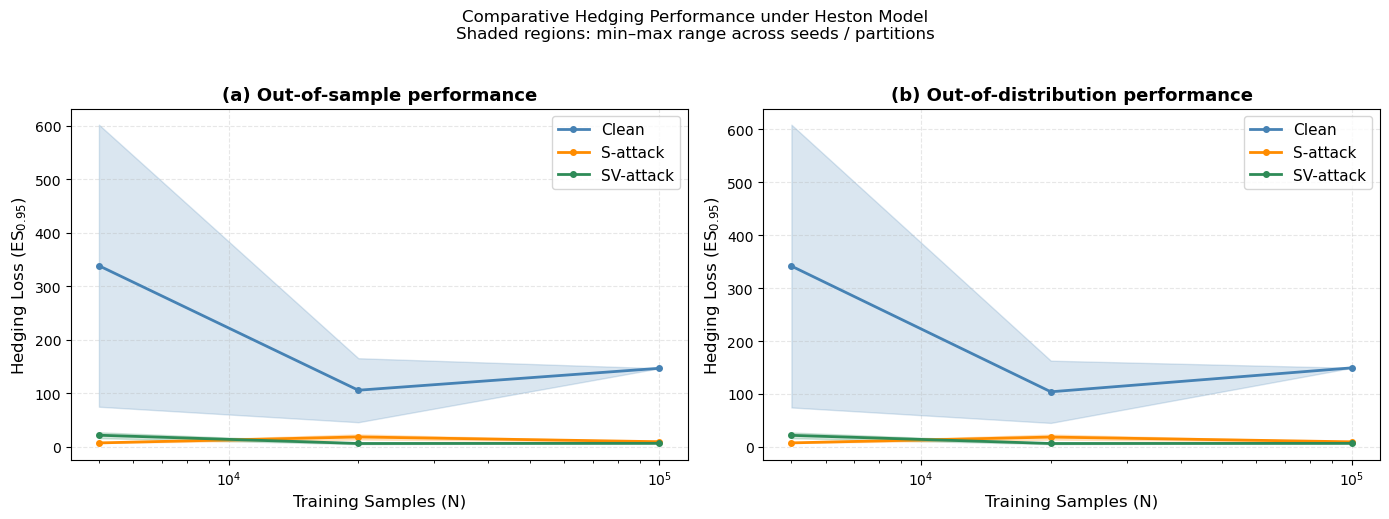

Figure saved → results/heston_figure1_adversarial.png


In [9]:
# ── Plot Figure 1 — OOS and OOD Performance ───────────────────────────────────

COLORS = {'clean': 'steelblue', 's_attack': 'darkorange', 'sv_attack': 'seagreen'}
LABELS = {'clean': 'Clean', 's_attack': 'S-attack', 'sv_attack': 'SV-attack'}


def _plot_panel(ax, results_dict: dict, title: str) -> None:
    """Draw one panel: mean line + min-max shaded band across seeds."""
    for method in METHODS:
        means, mins_, maxs_ = [], [], []
        for N in N_SIZES:
            n_runs = min(M_TRAIN // N, N_SEEDS)
            vals   = [
                results_dict[(N, method, s)]
                for s in range(n_runs)
                if (N, method, s) in results_dict
            ]
            if vals:
                means.append(float(np.mean(vals)))
                mins_.append(float(np.min(vals)))
                maxs_.append(float(np.max(vals)))
            else:
                means.append(float('nan'))
                mins_.append(float('nan'))
                maxs_.append(float('nan'))

        ax.plot(N_SIZES, means, color=COLORS[method], label=LABELS[method],
                linewidth=2.0, marker='o', markersize=4)
        ax.fill_between(N_SIZES, mins_, maxs_, alpha=0.20, color=COLORS[method])

    ax.set_xscale('log')
    ax.set_xlabel('Training Samples (N)', fontsize=12)
    ax.set_ylabel(r'Hedging Loss (ES$_{0.95}$)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_plot_panel(axes[0], results_oos, '(a) Out-of-sample performance')
_plot_panel(axes[1], results_ood, '(b) Out-of-distribution performance')

fig.suptitle(
    'Comparative Hedging Performance under Heston Model\n'
    'Shaded regions: min–max range across seeds / partitions',
    fontsize=12, y=1.03,
)
plt.tight_layout()
plt.savefig('../results/heston_figure1_adversarial.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → results/heston_figure1_adversarial.png")

In [10]:
# ── Summary Table ──────────────────────────────────────────────────────────────
# Paper reports: at N=5,000, SV-Attack achieves 54% lower mean loss than clean.

N_small = N_SIZES[0]    # smallest N
N_large = N_SIZES[-1]   # largest N

def _get_mean(results_dict, N, method):
    n_runs = min(M_TRAIN // N, N_SEEDS)
    vals = [results_dict.get((N, method, s), float('nan')) for s in range(n_runs)]
    return float(np.nanmean(vals))

print(f"\n{'':28s}  {'N='+str(N_small):>10s}  {'N='+str(N_large):>10s}")
print("-" * 52)
for label, results in [('OOS', results_oos), ('OOD', results_ood)]:
    for method in METHODS:
        v_small = _get_mean(results, N_small, method)
        v_large = _get_mean(results, N_large, method)
        print(f"  {label} {LABELS[method]:24s}  {v_small:10.4f}  {v_large:10.4f}")
    print()

# Improvement of SV-attack over clean at smallest N (OOS)
oos_clean  = _get_mean(results_oos, N_small, 'clean')
oos_sv_atk = _get_mean(results_oos, N_small, 'sv_attack')
if oos_clean > 0 and not np.isnan(oos_sv_atk):
    pct = 100 * (oos_clean - oos_sv_atk) / oos_clean
    print(f"SV-attack vs Clean at N={N_small}: {pct:.1f}% lower OOS loss"
          f"  ({oos_sv_atk:.3f} vs {oos_clean:.3f})")
    print("(Paper reports 54% lower at N=5,000 for the full experiment)")


                                  N=5000    N=100000
----------------------------------------------------
  OOS Clean                       338.7807    147.0966
  OOS S-attack                      7.6089      9.8535
  OOS SV-attack                    21.9614      6.8200

  OOD Clean                       341.4825    149.3859
  OOD S-attack                      7.7167      9.7117
  OOD SV-attack                    21.9272      6.8190

SV-attack vs Clean at N=5000: 93.5% lower OOS loss  (21.961 vs 338.781)
(Paper reports 54% lower at N=5,000 for the full experiment)
